# 01 — SCGM Text BTP Experiment

Notebook expérimental pour le pipeline SCGM-G sur embeddings texte fixes (sous-corpus BTP).


## 1. Objectif de l'expérience

- Source = BTP (segments de récits d'accidents).
- Labels macro = A0, A1, B, C (superclasses SCGM).
- SCGM apprend des ancres macro `mu_y` et des centres latents `mu_z`.
- Les composantes latentes servent à explorer des motifs intra-macro non observés.
- `pred_subtype` n'est pas un label expert : diagnostic exploratoire uniquement.


## 2. Imports et configuration


In [35]:
from pathlib import Path
import json
import os
import platform
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
import yaml

from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [48]:
# Parameters
DATA_CSV = "dataset/data_btp.csv"
EMB_CSV = "embeddings/Qwen3-Embedding-0.6B_btp.csv"
OUTPUT_DIR = "runs/scgm_text_qwen06_notebook"
LABEL_COL = "pred_label"
PRED_OK_COL = "pred_ok"
GROUP_COL = "accident_id"
SEED = 42
VAL_RATIO = 0.1
RUN_FULL_TRAINING = True
EPOCHS_FAST = 10
EPOCHS_FULL = 100
BATCH_SIZE = 512
HIDDIM = 128
N_SUBCLASS = 32
TAU = 0.1
ALPHA = 0.5
LMD = 25
N_ITER_ESTEP = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4
WITH_MLP = True
TSNE_SAMPLE_SIZE = 8000


In [49]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "scgm_text").is_dir() and (candidate / "scripts").is_dir():
            return candidate
    raise FileNotFoundError("Impossible de localiser la racine du dépôt (scgm_text/ + scripts/).")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

from scgm_text.dataset_text_embeddings import (
    ID2LABEL,
    LABEL2ID,
    TextEmbeddingDataset,
    split_by_group,
)
from scgm_text.utils_io import create_doc_id_if_missing, ensure_dir, get_dim_columns, load_json, set_seed

OUTPUT_PATH = Path(OUTPUT_DIR)
EXPORTS_DIR = OUTPUT_PATH / "exports"
EVAL_DIR = OUTPUT_PATH / "evaluation"
FIGURES_DIR = OUTPUT_PATH / "figures"
TABLES_DIR = OUTPUT_PATH / "tables"
for folder in [OUTPUT_PATH, EXPORTS_DIR, EVAL_DIR, FIGURES_DIR, TABLES_DIR]:
    ensure_dir(str(folder))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = EPOCHS_FULL if RUN_FULL_TRAINING else EPOCHS_FAST
set_seed(SEED)


def save_fig(name: str) -> Path:
    path = FIGURES_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


def display_df_for_paper(df: pd.DataFrame, name: str) -> Path:
    path = TABLES_DIR / name
    df.to_csv(path, index=False)
    display(df)
    return path


def run_cli(cmd, stream=True):
    print(" ".join(cmd))
    env = os.environ.copy()
    env["PYTHONUNBUFFERED"] = "1"
    if stream:
        completed = subprocess.run(cmd, cwd=REPO_ROOT, env=env, check=False)
        if completed.returncode != 0:
            raise subprocess.CalledProcessError(completed.returncode, cmd)
        return completed
    completed = subprocess.run(
        cmd,
        cwd=REPO_ROOT,
        env=env,
        check=False,
        capture_output=True,
        text=True,
    )
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    if completed.returncode != 0:
        raise subprocess.CalledProcessError(
            completed.returncode,
            cmd,
            output=completed.stdout,
            stderr=completed.stderr,
        )
    return completed


def show_training_progress(log_path=OUTPUT_PATH / "logs.csv"):
    if not Path(log_path).exists():
        print("Aucun logs.csv pour le moment.")
        return
    logs_df = pd.read_csv(log_path)
    display(logs_df.tail(5))
    if len(logs_df) == 0:
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    logs_df.plot(x="epoch", y=["train_loss", "loss_macro", "loss_latent"], ax=axes[0])
    logs_df.plot(x="epoch", y=["val_macro_f1", "val_balanced_acc", "val_acc"], ax=axes[1])
    plt.show()

print(f"REPO_ROOT={REPO_ROOT}")
print(f"OUTPUT_DIR={OUTPUT_PATH}")
print(f"DEVICE={device} | EPOCHS={epochs}")


REPO_ROOT=C:\Users\aho\Documents\analysis factor project\SCGM\SCGM
OUTPUT_DIR=runs\scgm_text_qwen06_notebook
DEVICE=cuda | EPOCHS=100


## 3. Vérification environnement


In [50]:
env_info = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "sklearn": sklearn.__version__,
    "device": str(device),
    "cuda_available": torch.cuda.is_available(),
    "cpu_count": os.cpu_count(),
}
if torch.cuda.is_available():
    env_info["gpu_name"] = torch.cuda.get_device_name(0)
    env_info["gpu_total_gb"] = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2)
pd.Series(env_info)


python                                        3.12.4
torch                                    2.5.1+cu118
pandas                                         2.2.1
numpy                                         1.26.4
sklearn                                        1.7.2
device                                          cuda
cuda_available                                  True
cpu_count                                         28
gpu_name          NVIDIA GeForce RTX 4090 Laptop GPU
gpu_total_gb                                   17.17
dtype: object

## 4. Chargement et inspection des données brutes


In [51]:
raw_df = pd.read_csv(DATA_CSV)
print("shape:", raw_df.shape)
display(raw_df.head())
print("colonnes:", list(raw_df.columns))
print("accidents distincts:", raw_df[GROUP_COL].nunique())
print("pred_ok True/False:", raw_df[PRED_OK_COL].astype(str).str.lower().value_counts().to_dict())
print("NaN pred_label:", int(raw_df[LABEL_COL].isna().sum()))
print("distribution pred_label (brute):")
display(raw_df[LABEL_COL].value_counts(dropna=False))

shape: (42309, 18)


,accident_id,fact_id,sentence,Unnamed: 0,division,equipment_involved,company_code,accident_summary,word_count,pred_label,pred_subtype,pred_severity,pred_confidence,pred_justification,pred_ok,pred_raw,pred_error,pred_source
0,EB16DB93EC8D4705C1258D7A002EF784,1,L'accident de travail a eu lieu sur un chantie...,20,43,510328 - Autre type d'échafaudage,4391B - Travaux de couverture par éléments,L'accident de travail a eu lieu sur un chantie...,32,A0,A0_ENV_LOCATION,NONE,0.95,Contexte utilisé: non. Indice principal: « cha...,True,"<think>\n\n</think>\n\n{\n ""label"": ""A0"",\n ...",NaN,cache
1,EB16DB93EC8D4705C1258D7A002EF784,2,Un échafaudage de pied est positionné sur un m...,20,43,510328 - Autre type d'échafaudage,4391B - Travaux de couverture par éléments,L'accident de travail a eu lieu sur un chantie...,10,A0,A0_ENV_LOCATION,NONE,0.95,Contexte utilisé: non. Indice principal: « éch...,True,"<think>\n\n</think>\n\n{\n ""label"": ""A0"",\n ...",NaN,cache
2,EB16DB93EC8D4705C1258D7A002EF784,3,L'échafaudage nest pas conforme : il est situ...,20,43,510328 - Autre type d'échafaudage,4391B - Travaux de couverture par éléments,L'accident de travail a eu lieu sur un chantie...,60,A1,A1_LAYOUT_ACCESS,NONE,0.95,Contexte utilisé: non. Indice principal: « il ...,True,"<think>\n\n</think>\n\n{\n ""label"": ""A1"",\n ...",NaN,cache
3,EB16DB93EC8D4705C1258D7A002EF784,4,La rive opposée n'a pas de protection collective.,20,43,510328 - Autre type d'échafaudage,4391B - Travaux de couverture par éléments,L'accident de travail a eu lieu sur un chantie...,9,A1,A1_SUPPORT_SURFACE,NONE,0.95,Contexte utilisé: non. Indice principal: « la ...,True,"<think>\n\n</think>\n\n{\n ""label"": ""A1"",\n ...",NaN,cache
4,EB16DB93EC8D4705C1258D7A002EF784,5,Une échelle de toit est posée sur le toit en s...,20,43,510328 - Autre type d'échafaudage,4391B - Travaux de couverture par éléments,L'accident de travail a eu lieu sur un chantie...,18,A1,A1_SUPPORT_SURFACE,NONE,0.95,Contexte utilisé: non. Indice principal: « san...,True,"<think>\n\n</think>\n\n{\n ""label"": ""A1"",\n ...",NaN,cache


colonnes: ['accident_id', 'fact_id', 'sentence', 'Unnamed: 0', 'division', 'equipment_involved', 'company_code', 'accident_summary', 'word_count', 'pred_label', 'pred_subtype', 'pred_severity', 'pred_confidence', 'pred_justification', 'pred_ok', 'pred_raw', 'pred_error', 'pred_source']
accidents distincts: 6040
pred_ok True/False: {'true': 41457, 'false': 852}
NaN pred_label: 852
distribution pred_label (brute):


pred_label
A0     22206
C      11402
A1      4883
B       2966
NaN      852
Name: count, dtype: int64

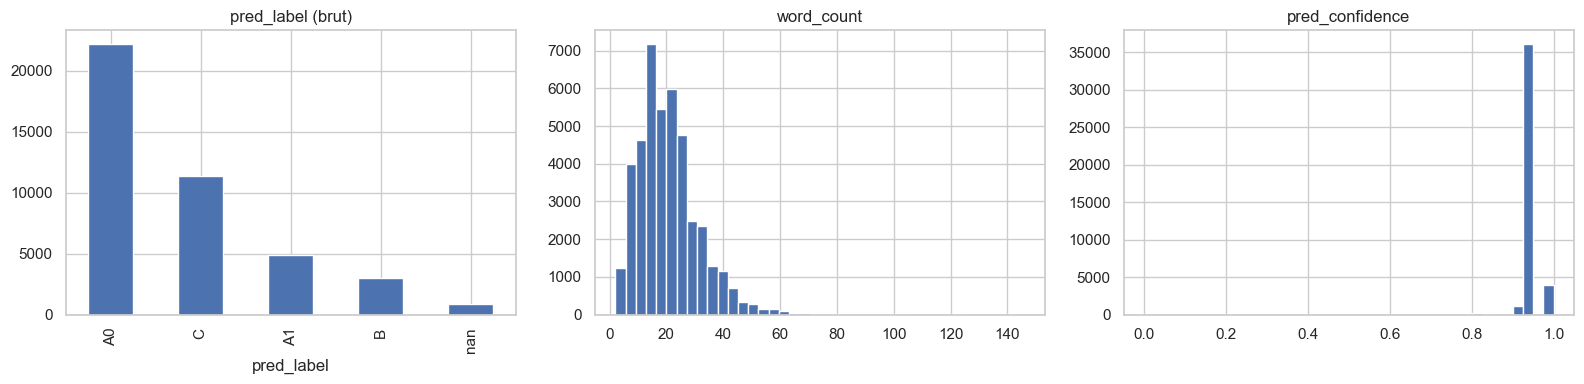

WindowsPath('runs/scgm_text_qwen06_notebook/figures/01_raw_distributions.png')

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
raw_df[LABEL_COL].value_counts(dropna=False).plot(kind="bar", ax=axes[0], title="pred_label (brut)")
if "word_count" in raw_df.columns:
    raw_df["word_count"].hist(ax=axes[1], bins=40)
    axes[1].set_title("word_count")
if "pred_confidence" in raw_df.columns:
    raw_df["pred_confidence"].dropna().hist(ax=axes[2], bins=40)
    axes[2].set_title("pred_confidence")
save_fig("01_raw_distributions.png")


## 5. Chargement et inspection des embeddings


In [53]:
emb_preview = pd.read_csv(EMB_CSV, nrows=5)
display(emb_preview.iloc[:, :8])
header = pd.read_csv(EMB_CSV, nrows=0)
dim_cols = get_dim_columns(header)
print("input_dim:", len(dim_cols))

doc_ids = pd.read_csv(EMB_CSV, usecols=["doc_id"])["doc_id"]
print("embedding rows:", len(doc_ids))
print("doc_id min/max:", int(doc_ids.min()), int(doc_ids.max()))
print("doc_id unique:", doc_ids.nunique() == len(doc_ids))

raw_with_doc = create_doc_id_if_missing(raw_df)
assert len(raw_with_doc) == 42309
assert doc_ids.min() == 1 and doc_ids.max() == len(raw_with_doc)


,doc_id,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7
0,1,0.046143,-0.030884,-0.004425,0.020264,0.012207,-0.027466,-0.008911
1,2,0.059814,-0.038330,-0.004181,0.012146,-0.011353,0.026367,0.031982
2,3,0.083984,-0.048584,-0.006439,0.005188,0.001320,0.020142,0.057373
3,4,-0.001923,-0.040771,-0.003098,0.023193,0.044678,-0.024292,-0.043701
4,5,0.050781,-0.043213,-0.007019,0.026123,-0.005310,0.013855,0.020264


input_dim: 1024
embedding rows: 42309
doc_id min/max: 1 42309
doc_id unique: True


## 6. Dataset filtré SCGM


In [54]:
dataset = TextEmbeddingDataset(
    data_csv=DATA_CSV,
    emb_csv=EMB_CSV,
    label_col=LABEL_COL,
    pred_ok_col=PRED_OK_COL,
    group_col=GROUP_COL,
)
meta = dataset.get_metadata_df()
print("lignes filtrées:", len(dataset))
print("distribution macro:", dataset.get_label_distribution())
print("accidents distincts:", meta[GROUP_COL].nunique())
print("input_dim:", dataset.get_input_dim())

examples = (
    meta.groupby(LABEL_COL, group_keys=False)
    .apply(lambda g: g.sample(min(2, len(g)), random_state=SEED))[["accident_id", "fact_id", LABEL_COL, "sentence"]]
)
display(examples)


lignes filtrées: 41457
distribution macro: {'A0': 22206, 'C': 11402, 'A1': 4883, 'B': 2966}
accidents distincts: 6040
input_dim: 1024


C:\Users\aho\AppData\Local\Temp\ipykernel_37656\3228579523.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(2, len(g)), random_state=SEED))[["accident_id", "fact_id", LABEL_COL, "sentence"]]


,accident_id,fact_id,pred_label,sentence
19642,93707FDEE38910C8C125719D0056748A,20097,A0,"Pour la maintenir verticalement, il devait la ..."
23723,EC0CF3E2280634A3C125719D0055B17D,24246,A0,"La fin de la semaine étant arrivée, la tâche d..."
8787,BB5B4FFE8F0F2DE8C12581A300364E5F,8998,A1,Le chantier était terminé depuis un mois et l'...
3284,61972271C4A320AEC1258A27002D647C,3361,A1,"Lors du basculement, les chenilles étaient ort..."
34255,7E2F685CDFCA934FC125719D005274B9,34975,B,"Lors de cette manoeuvre, le dumper a dépassé l..."
13606,AB558AC0B28DA251C1257810002EA035,13925,B,Une plaque ondulée translucide sur laquelle el...
30326,6D7D32E6796153C0C125719D0053B9F0,30987,C,Elle est décédée.
8705,0ADEE82F7A5287BBC12581BF002335A0,8916,C,L'avant-bras heurte le bâti du tour parallèle.


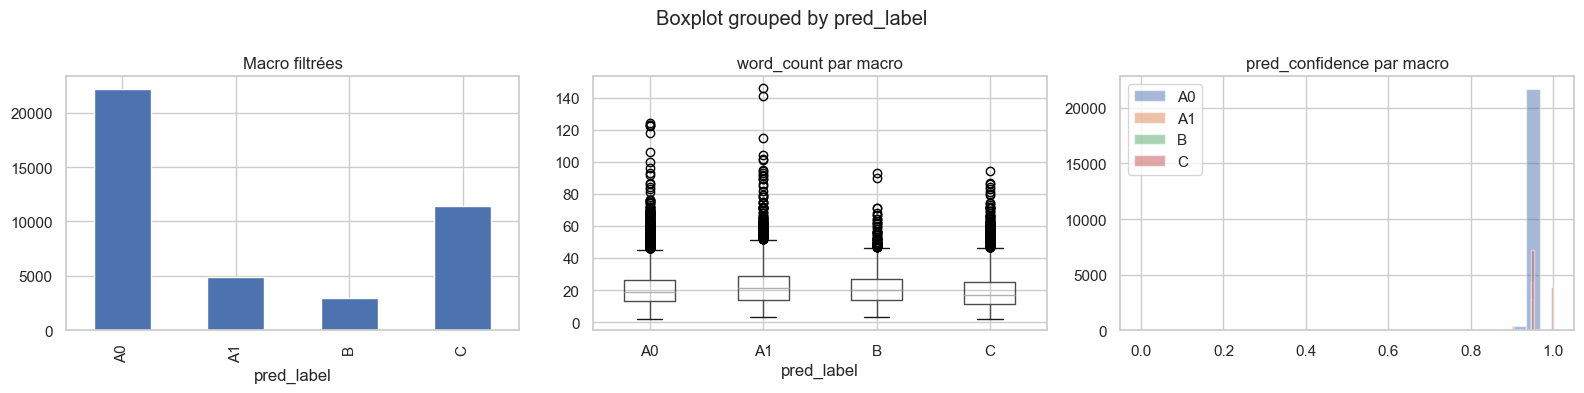

WindowsPath('runs/scgm_text_qwen06_notebook/figures/02_filtered_distributions.png')

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
meta[LABEL_COL].value_counts().reindex(["A0", "A1", "B", "C"]).plot(kind="bar", ax=axes[0], title="Macro filtrées")
if "word_count" in meta.columns:
    meta.boxplot(column="word_count", by=LABEL_COL, ax=axes[1])
    axes[1].set_title("word_count par macro")
if "pred_confidence" in meta.columns:
    for label in ["A0", "A1", "B", "C"]:
        subset = meta.loc[meta[LABEL_COL] == label, "pred_confidence"].dropna()
        axes[2].hist(subset, bins=30, alpha=0.5, label=label)
    axes[2].legend()
    axes[2].set_title("pred_confidence par macro")
save_fig("02_filtered_distributions.png")

## 7. Split train/validation par accident_id


In [56]:
train_idx, val_idx = split_by_group(dataset, val_ratio=VAL_RATIO, seed=SEED)
train_meta = meta.iloc[train_idx].copy()
val_meta = meta.iloc[val_idx].copy()
print("train units:", len(train_idx), "| val units:", len(val_idx))
print("train accidents:", train_meta[GROUP_COL].nunique(), "| val accidents:", val_meta[GROUP_COL].nunique())
intersection = set(train_meta[GROUP_COL]).intersection(set(val_meta[GROUP_COL]))
print("intersection accident_id train/val:", len(intersection))
print("train label dist:", train_meta[LABEL_COL].value_counts().to_dict())
print("val label dist:", val_meta[LABEL_COL].value_counts().to_dict())


train units: 37370 | val units: 4087
train accidents: 5436 | val accidents: 604
intersection accident_id train/val: 0
train label dist: {'A0': 20038, 'C': 10248, 'A1': 4422, 'B': 2662}
val label dist: {'A0': 2168, 'C': 1154, 'A1': 461, 'B': 304}


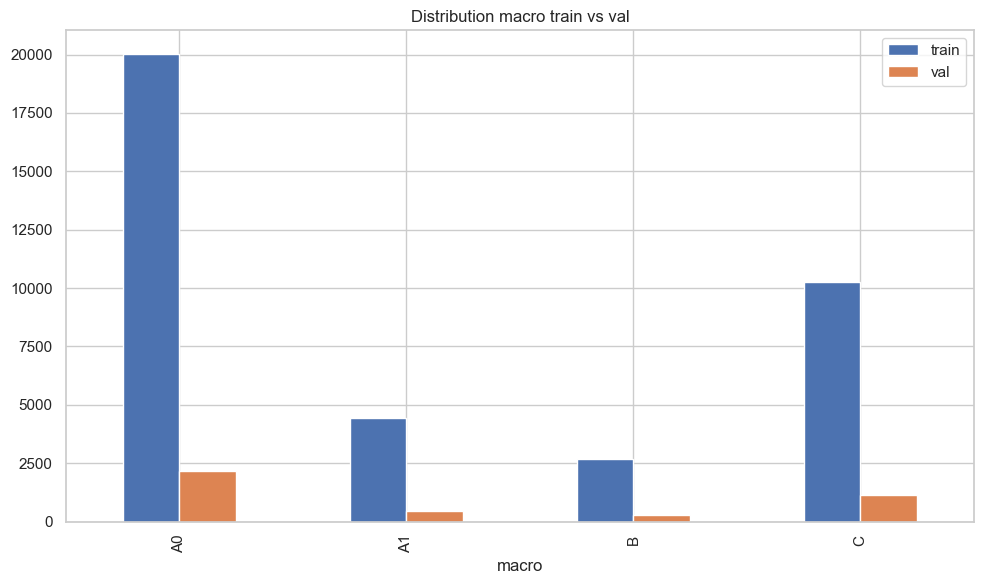

,macro,train,val
0,A0,20038,2168
1,A1,4422,461
2,B,2662,304
3,C,10248,1154


WindowsPath('runs/scgm_text_qwen06_notebook/tables/split_train_val.csv')

In [57]:
split_df = pd.DataFrame({
    "macro": ["A0", "A1", "B", "C"],
    "train": [int((train_meta[LABEL_COL] == m).sum()) for m in ["A0", "A1", "B", "C"]],
    "val": [int((val_meta[LABEL_COL] == m).sum()) for m in ["A0", "A1", "B", "C"]],
}).set_index("macro")
split_df.plot(kind="bar", title="Distribution macro train vs val")
plt.xlabel("macro")
save_fig("03_train_val_macro.png")
display_df_for_paper(split_df.reset_index(), "split_train_val.csv")


## 8. Entraînement SCGM-G texte depuis le notebook

- **MODE RAPIDE** : `RUN_FULL_TRAINING = False` (10 epochs par défaut).
- **MODE COMPLET** : `RUN_FULL_TRAINING = True` (100 epochs).
- L'entraînement s'exécute **dans le kernel du notebook** via `run_training()` (même logique que le script CLI, sans sous-processus).
- Suivi : barres `tqdm`, messages d'époque, `logs.csv`, puis `show_training_progress()`.


In [58]:
import argparse
import importlib.util

train_script_path = REPO_ROOT / "scripts" / "train_scgm_text.py"
train_module_name = "scgm_train_text"
sys.modules.pop(train_module_name, None)
train_spec = importlib.util.spec_from_file_location(train_module_name, train_script_path)
scgm_train_text = importlib.util.module_from_spec(train_spec)
sys.modules[train_module_name] = scgm_train_text
train_spec.loader.exec_module(scgm_train_text)

train_args = argparse.Namespace(
    config=None,
    data_csv=DATA_CSV,
    emb_csv=EMB_CSV,
    output_dir=str(OUTPUT_PATH),
    label_col=LABEL_COL,
    pred_ok_col=PRED_OK_COL,
    group_col=GROUP_COL,
    batch_size=BATCH_SIZE,
    epochs=epochs,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    hiddim=HIDDIM,
    n_class=4,
    n_subclass=N_SUBCLASS,
    tau=TAU,
    alpha=ALPHA,
    lmd=LMD,
    n_iter_estep=N_ITER_ESTEP,
    val_ratio=VAL_RATIO,
    seed=SEED,
    device="cuda" if torch.cuda.is_available() else "cpu",
    with_mlp=WITH_MLP,
    num_workers=0,
    smoke_epochs=None,
)

scgm_train_text.run_training(train_args)


Device effectif: cuda
sinkhornknopp: error:  0.016077774967758307 step  41
opt took 0.00min,   41iters


Epoch 1/100 | train_loss=2.6830 | val_macro_f1=0.5488 | val_balanced_acc=0.5435


Epoch 2/100 | train_loss=2.1292 | val_macro_f1=0.5331 | val_balanced_acc=0.5088


Epoch 3/100 | train_loss=1.8595 | val_macro_f1=0.4644 | val_balanced_acc=0.4446


Epoch 4/100 | train_loss=1.6599 | val_macro_f1=0.4246 | val_balanced_acc=0.4142


...

Epoch 96/100 | train_loss=0.5159 | val_macro_f1=0.5119 | val_balanced_acc=0.4959


Epoch 97/100 | train_loss=0.5238 | val_macro_f1=0.5137 | val_balanced_acc=0.4957


Epoch 98/100 | train_loss=0.5348 | val_macro_f1=0.5073 | val_balanced_acc=0.4932


Epoch 99/100 | train_loss=0.5418 | val_macro_f1=0.5098 | val_balanced_acc=0.4914


Epoch 100/100 | train_loss=0.5535 | val_macro_f1=0.5016 | val_balanced_acc=0.4862


## 9. Courbes d'entraînement


,epoch,train_loss,loss_macro,loss_latent,val_acc,val_macro_f1,val_balanced_acc,rankme_global,c1_global,c10_global
95,96,0.515925,0.005340,1.021171,0.712503,0.511934,0.495890,53.920345,0.123737,0.488581
96,97,0.523787,0.006588,1.034397,0.718375,0.513668,0.495690,53.920223,0.122529,0.492819
97,98,0.534775,0.009503,1.050544,0.710546,0.507344,0.493215,53.698242,0.118511,0.479029
98,99,0.541782,0.010714,1.062136,0.710790,0.509824,0.491408,54.618668,0.114811,0.478504
99,100,0.553462,0.018813,1.069299,0.703695,0.501591,0.486241,54.674274,0.119435,0.485724


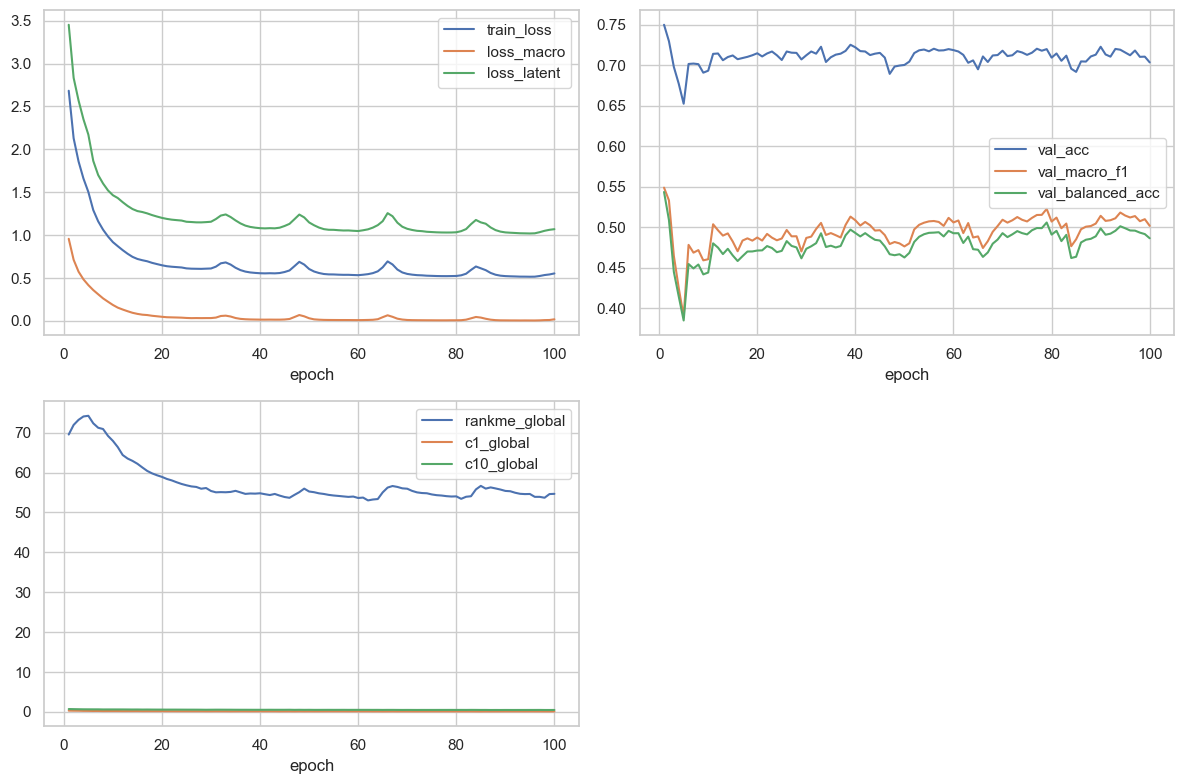

,epoch,train_loss,loss_macro,loss_latent,val_acc,val_macro_f1,val_balanced_acc,rankme_global,c1_global,c10_global
0,1,2.682979,0.957116,3.451726,0.750184,0.548815,0.543459,69.546875,0.321551,0.716174
1,2,2.129192,0.712640,2.833103,0.729875,0.533098,0.508849,71.953362,0.301656,0.690540
2,3,1.859503,0.574431,2.570145,0.698067,0.464389,0.444639,73.224777,0.292314,0.668597
3,4,1.659937,0.484523,2.350828,0.677269,0.424573,0.414201,74.077370,0.261066,0.649837
4,5,1.503114,0.417379,2.171470,0.652557,0.389411,0.384614,74.245903,0.254171,0.642234
...,...,...,...,...,...,...,...,...,...,...
95,96,0.515925,0.005340,1.021171,0.712503,0.511934,0.495890,53.920345,0.123737,0.488581
96,97,0.523787,0.006588,1.034397,0.718375,0.513668,0.495690,53.920223,0.122529,0.492819
97,98,0.534775,0.009503,1.050544,0.710546,0.507344,0.493215,53.698242,0.118511,0.479029
98,99,0.541782,0.010714,1.062136,0.710790,0.509824,0.491408,54.618668,0.114811,0.478504


WindowsPath('runs/scgm_text_qwen06_notebook/tables/training_logs.csv')

In [59]:
logs = pd.read_csv(OUTPUT_PATH / "logs.csv")
display(logs.tail())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
logs.plot(x="epoch", y=["train_loss", "loss_macro", "loss_latent"], ax=axes[0, 0])
logs.plot(x="epoch", y=["val_acc", "val_macro_f1", "val_balanced_acc"], ax=axes[0, 1])
logs.plot(x="epoch", y=["rankme_global", "c1_global", "c10_global"], ax=axes[1, 0])
axes[1, 1].axis("off")
save_fig("04_training_curves.png")
display_df_for_paper(logs, "training_logs.csv")


## 10. Meilleur checkpoint


In [60]:
checkpoint = torch.load(OUTPUT_PATH / "best_model.pt", map_location="cpu")
config = load_json(str(OUTPUT_PATH / "config.json"))
summary_ckpt = {
    "input_dim": checkpoint.get("input_dim"),
    "label2id": checkpoint.get("label2id"),
    "train_size": len(checkpoint.get("train_idx", [])),
    "val_size": len(checkpoint.get("val_idx", [])),
    "args": checkpoint.get("args", {}),
}
display(pd.json_normalize(summary_ckpt["args"]))
pd.Series({
    "input_dim": summary_ckpt["input_dim"],
    "train_size": summary_ckpt["train_size"],
    "val_size": summary_ckpt["val_size"],
})


C:\Users\aho\AppData\Local\Temp\ipykernel_37656\905488144.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(OUTPUT_PATH / "best_model.pt", map_loca

,config,data_csv,emb_csv,output_dir,label_col,pred_ok_col,group_col,batch_size,epochs,lr,...,tau,alpha,lmd,n_iter_estep,val_ratio,seed,device,with_mlp,num_workers,smoke_epochs
0,None,dataset/data_btp.csv,embeddings/Qwen3-Embedding-0.6B_btp.csv,runs\scgm_text_qwen06_notebook,pred_label,pred_ok,accident_id,512,100,0.001,...,0.1,0.5,25,5,0.1,42,cuda,True,0,None


input_dim      1024
train_size    37370
val_size       4087
dtype: int64

## 11. Export des sorties


In [61]:
export_cmd = [
    sys.executable,
    "scripts/export_scgm_text_outputs.py",
    "--data_csv", DATA_CSV,
    "--emb_csv", EMB_CSV,
    "--checkpoint", str(OUTPUT_PATH / "best_model.pt"),
    "--output_dir", str(EXPORTS_DIR),
    "--label_col", LABEL_COL,
    "--pred_ok_col", PRED_OK_COL,
    "--group_col", GROUP_COL,
    "--batch_size", str(BATCH_SIZE),
    "--device", "cuda" if torch.cuda.is_available() else "cpu",
]
run_cli(export_cmd)
exported = sorted(p.name for p in EXPORTS_DIR.iterdir())
print("artefacts exportés:", exported)


C:\ProgramData\anaconda3\python.exe scripts/export_scgm_text_outputs.py --data_csv dataset/data_btp.csv --emb_csv embeddings/Qwen3-Embedding-0.6B_btp.csv --checkpoint runs\scgm_text_qwen06_notebook\best_model.pt --output_dir runs\scgm_text_qwen06_notebook\exports --label_col pred_label --pred_ok_col pred_ok --group_col accident_id --batch_size 512 --device cuda
artefacts exportés: ['macro_predictions.csv', 'metadata_with_predictions.csv', 'mu_y.npy', 'mu_z.npy', 'prob_y_x.npy', 'prob_y_z.npy', 'prob_z_x.npy', 'projected_embeddings.npy', 'themes_by_macro_z.csv', 'themes_by_z.csv', 'z_assignments.csv']


## 12. Visualisation des embeddings projetés


C:\Users\aho\AppData\Local\Temp\ipykernel_37656\324636425.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = meta_pred.groupby(LABEL_COL, group_keys=False).apply(


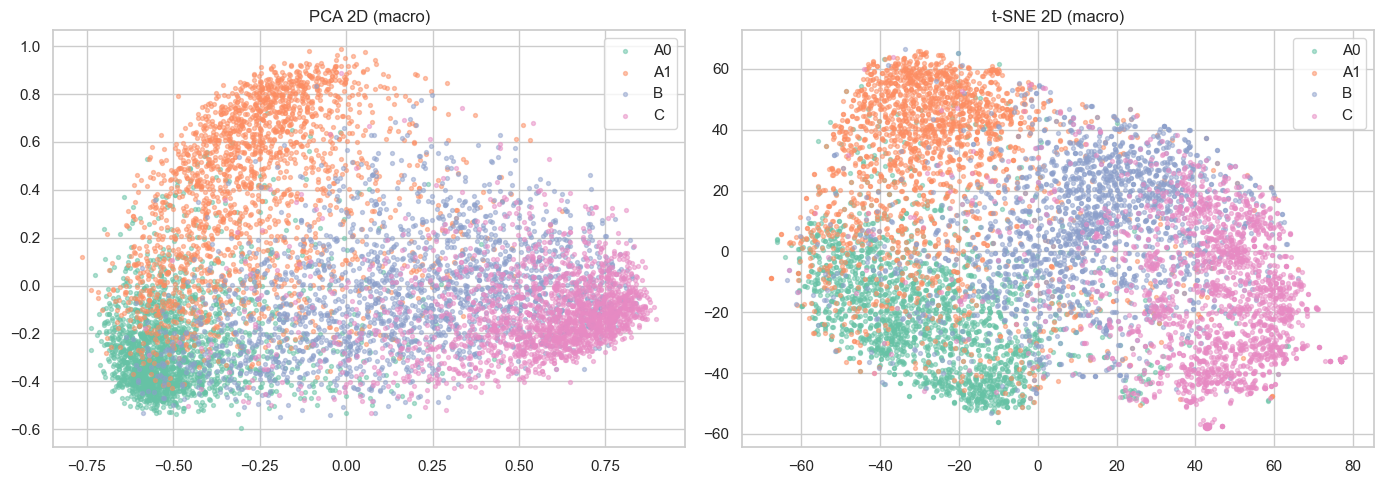

WindowsPath('runs/scgm_text_qwen06_notebook/figures/05_projection_macro.png')

In [62]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

projected = np.load(EXPORTS_DIR / "projected_embeddings.npy")
meta_pred = pd.read_csv(EXPORTS_DIR / "metadata_with_predictions.csv")

sample_df = meta_pred.groupby(LABEL_COL, group_keys=False).apply(
    lambda g: g.sample(min(len(g), max(1, TSNE_SAMPLE_SIZE // 4)), random_state=SEED)
)
if len(sample_df) > TSNE_SAMPLE_SIZE:
    sample_df = sample_df.sample(TSNE_SAMPLE_SIZE, random_state=SEED)
idx = sample_df.index.to_numpy()
sample_x = projected[idx]

pca = PCA(n_components=2, random_state=SEED)
pca_xy = pca.fit_transform(sample_x)
tsne = TSNE(n_components=2, random_state=SEED, init="pca", learning_rate="auto")
tsne_xy = tsne.fit_transform(sample_x)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in zip(["A0", "A1", "B", "C"], sns.color_palette("Set2", 4)):
    mask = sample_df[LABEL_COL].values == label
    axes[0].scatter(pca_xy[mask, 0], pca_xy[mask, 1], s=8, alpha=0.5, label=label, c=[color])
    axes[1].scatter(tsne_xy[mask, 0], tsne_xy[mask, 1], s=8, alpha=0.5, label=label, c=[color])
axes[0].set_title("PCA 2D (macro)")
axes[1].set_title("t-SNE 2D (macro)")
axes[0].legend()
axes[1].legend()
save_fig("05_projection_macro.png")


## 13. Analyse des centres macro mu_y


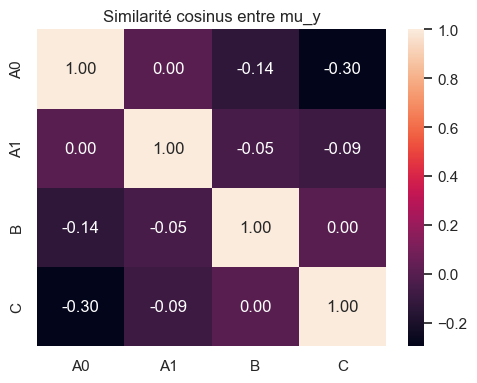

,macro,norm
0,A0,1.728329
1,A1,1.687467
2,B,1.576613
3,C,1.824975


WindowsPath('runs/scgm_text_qwen06_notebook/tables/mu_y_norms.csv')

In [63]:
from sklearn.metrics.pairwise import cosine_similarity

mu_y = np.load(EXPORTS_DIR / "mu_y.npy")
macro_names = ["A0", "A1", "B", "C"]
cos_y = cosine_similarity(mu_y)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cos_y, annot=True, fmt=".2f", xticklabels=macro_names, yticklabels=macro_names, ax=ax)
ax.set_title("Similarité cosinus entre mu_y")
save_fig("06_mu_y_cosine.png")

norms = np.linalg.norm(mu_y, axis=1)
macro_table = pd.DataFrame({"macro": macro_names, "norm": norms})
display_df_for_paper(macro_table, "mu_y_norms.csv")


## 14. Analyse des centres latents mu_z


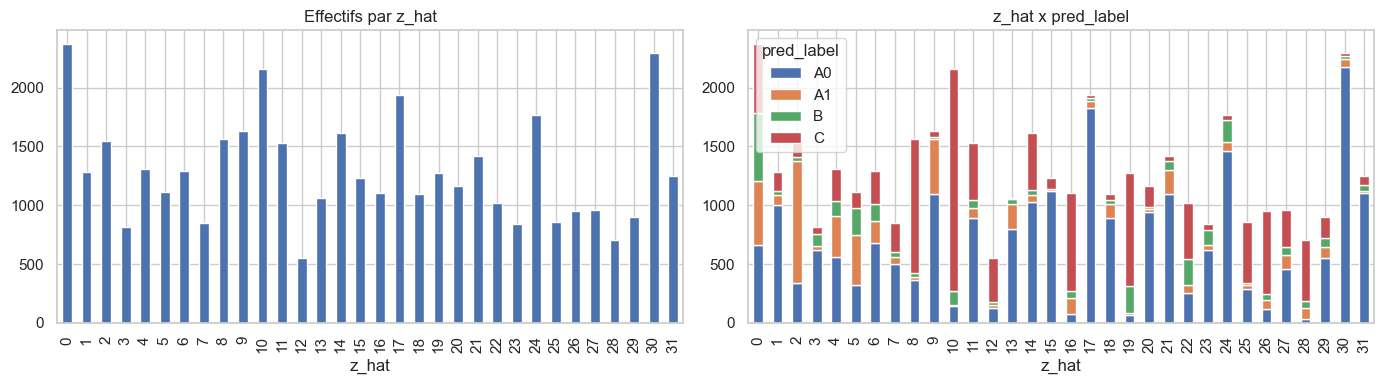

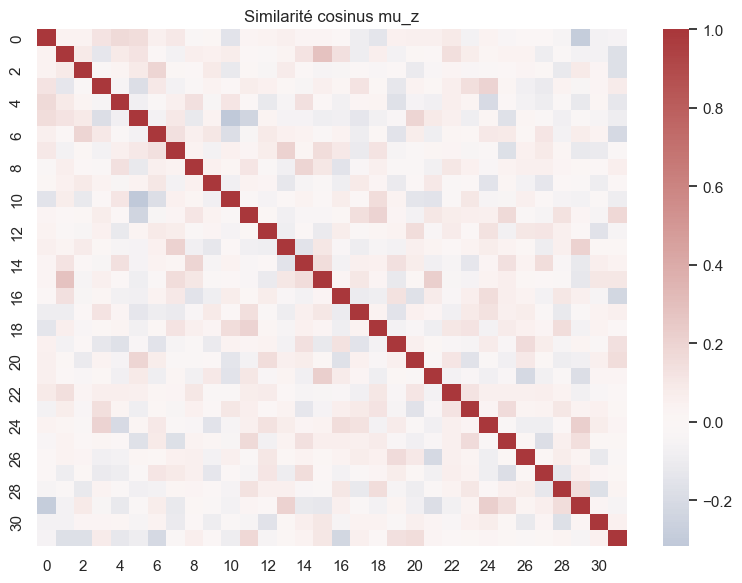

WindowsPath('runs/scgm_text_qwen06_notebook/figures/08_mu_z_cosine.png')

In [64]:
mu_z = np.load(EXPORTS_DIR / "mu_z.npy")
z_counts = meta_pred["z_hat"].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
z_counts.plot(kind="bar", ax=axes[0], title="Effectifs par z_hat")
pd.crosstab(meta_pred["z_hat"], meta_pred[LABEL_COL]).plot(kind="bar", stacked=True, ax=axes[1], legend=True)
axes[1].set_title("z_hat x pred_label")
save_fig("07_mu_z_usage.png")

cos_z = cosine_similarity(mu_z)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cos_z, cmap="vlag", center=0, ax=ax)
ax.set_title("Similarité cosinus mu_z")
save_fig("08_mu_z_cosine.png")


## 15. Thèmes par composante z


In [65]:
themes_z = pd.read_csv(EXPORTS_DIR / "themes_by_z.csv")
themes_macro = pd.read_csv(EXPORTS_DIR / "themes_by_macro_z.csv")
display(themes_macro)
top_components = themes_z.sort_values("n_units", ascending=False).head(15)
display(top_components[["z_id", "dominant_macro", "n_units", "top_words"]])
display_df_for_paper(top_components, "top_themes_by_z.csv")


,macro,macro_name,n_components,n_units,top_words
0,A0,A0,21,28604,victime été salarié ans chute était véhicule p...
1,A1,A1,2,2664,était échafaudage été chantier hauteur avait a...
2,C,C,9,10189,victime chute fait mètres décédée hauteur été ...


,z_id,dominant_macro,n_units,top_words
0,0,A0,2369,victime été salarié ans chute était véhicule p...
30,30,A0,2292,toiture chantier travaux bâtiment deux trois s...
10,10,C,2157,victime chute fait mètres décédée hauteur été ...
17,17,A0,1938,entreprise chantier ans toiture chef travaux é...
24,24,A0,1768,chantier deux camion était place chef équipe p...
9,9,A0,1632,été était sécurité protection entreprise deux ...
14,14,A0,1611,ans victime âgé chantier travaux entreprise ou...
8,8,C,1567,décédée victime ans maçon été âgé souffre coll...
2,2,A1,1547,était échafaudage été chantier hauteur avait a...
11,11,A0,1530,victime ans souffre deux chantier fractures ét...


,z_id,dominant_macro,n_units,top_words,top_sentences
0,0,A0,2369,victime été salarié ans chute était véhicule p...,1) perte d'équilibre du salarié en cours de dé...
30,30,A0,2292,toiture chantier travaux bâtiment deux trois s...,Trois salariés se trouvaient sur le toit dun ...
10,10,C,2157,victime chute fait mètres décédée hauteur été ...,"Il na fait état daucun signe de faiblesse, m..."
17,17,A0,1938,entreprise chantier ans toiture chef travaux é...,Le chef de chantier fait manoeuvrer les semi-r...
24,24,A0,1768,chantier deux camion était place chef équipe p...,"Pour voir de plus près, le chef de chantier mo..."
9,9,A0,1632,été était sécurité protection entreprise deux ...,"Aux dires de l'employeur, l'extension dispose ..."
14,14,A0,1611,ans victime âgé chantier travaux entreprise ou...,La victime - poseur de canalisations réseaux d...
8,8,C,1567,décédée victime ans maçon été âgé souffre coll...,"La victime, âgée de 43 ans, de sexe masculin, ..."
2,2,A1,1547,était échafaudage été chantier hauteur avait a...,L'échafaudage est situé à 7 mètres de hauteur ...
11,11,A0,1530,victime ans souffre deux chantier fractures ét...,Un chef d'équipe de 57 ans a fait un malaise c...


WindowsPath('runs/scgm_text_qwen06_notebook/tables/top_themes_by_z.csv')

## 16. Métriques géométriques


C:\ProgramData\anaconda3\python.exe scripts/evaluate_scgm_text.py --exports_dir runs\scgm_text_qwen06_notebook\exports --output_dir runs\scgm_text_qwen06_notebook\evaluation --label_col pred_label


,accuracy,macro_f1,balanced_accuracy,rankme_global,c1_global,c10_global,nmi_subtype,ari_subtype,subtype_diagnostic_note
0,0.754493,0.571244,0.559141,69.926262,0.315946,0.713199,0.163052,0.049213,pred_subtype is exploratory only and is not ex...


,macro,rankme,c1,c10
0,A0,76.012245,0.108119,0.595242
1,A1,74.066696,0.192534,0.651707
2,B,73.175728,0.169446,0.648545
3,C,72.768837,0.139219,0.652830


,scope,silhouette,davies_bouldin,calinski_harabasz
0,global,-0.032447,3.194877,750.735767
1,A0,0.014511,2.998834,266.832182
2,A1,-0.001129,3.014682,51.223691
3,B,-0.010951,2.979646,30.759406
4,C,0.025890,2.933003,143.961853


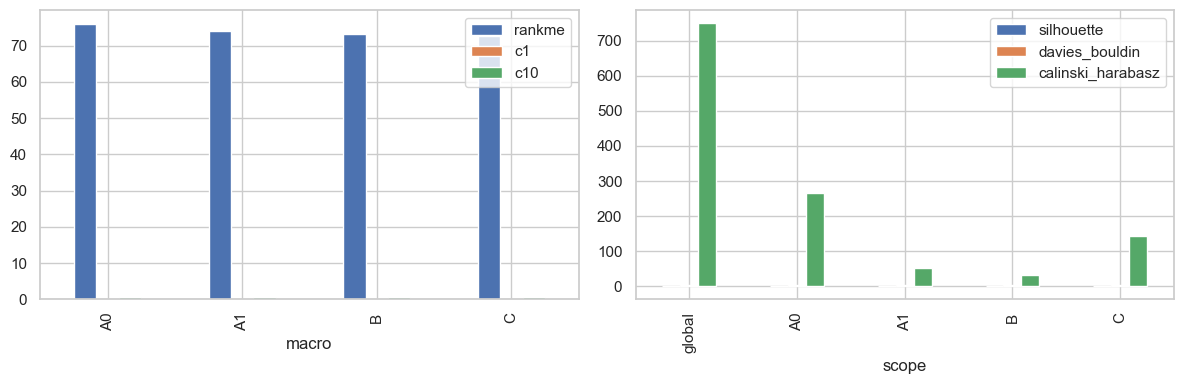

WindowsPath('runs/scgm_text_qwen06_notebook/figures/09_geometry_clustering.png')

In [66]:
eval_cmd = [
    sys.executable,
    "scripts/evaluate_scgm_text.py",
    "--exports_dir", str(EXPORTS_DIR),
    "--output_dir", str(EVAL_DIR),
    "--label_col", LABEL_COL,
]
run_cli(eval_cmd)

metrics_summary = pd.read_csv(EVAL_DIR / "metrics_summary.csv")
geometry_by_macro = pd.read_csv(EVAL_DIR / "geometry_by_macro.csv")
clustering_metrics = pd.read_csv(EVAL_DIR / "clustering_metrics.csv")
display(metrics_summary)
display(geometry_by_macro)
display(clustering_metrics)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
geometry_by_macro.plot(x="macro", y=["rankme", "c1", "c10"], kind="bar", ax=axes[0])
clustering_metrics.set_index("scope")[["silhouette", "davies_bouldin", "calinski_harabasz"]].plot(kind="bar", ax=axes[1])
save_fig("09_geometry_clustering.png")


## 17. Tableaux prêts pour papier / thèse


In [67]:
confusion = pd.read_csv(EVAL_DIR / "confusion_matrix.csv")
display_df_for_paper(metrics_summary, "paper_metrics_summary.csv")
display_df_for_paper(geometry_by_macro, "paper_geometry_by_macro.csv")
display_df_for_paper(clustering_metrics, "paper_clustering_metrics.csv")
display_df_for_paper(confusion, "paper_confusion_matrix.csv")
display_df_for_paper(themes_macro, "paper_themes_by_macro.csv")

notebook_summary = {
    "output_dir": str(OUTPUT_PATH),
    "exports_dir": str(EXPORTS_DIR),
    "evaluation_dir": str(EVAL_DIR),
    "figures_dir": str(FIGURES_DIR),
    "tables_dir": str(TABLES_DIR),
    "epochs": epochs,
    "device": str(device),
    "figure_files": sorted(p.name for p in FIGURES_DIR.glob("*.png")),
    "table_files": sorted(p.name for p in TABLES_DIR.glob("*.csv")),
}
with open(OUTPUT_PATH / "notebook_summary.json", "w", encoding="utf-8") as handle:
    json.dump(notebook_summary, handle, indent=2, ensure_ascii=False)
notebook_summary


,accuracy,macro_f1,balanced_accuracy,rankme_global,c1_global,c10_global,nmi_subtype,ari_subtype,subtype_diagnostic_note
0,0.754493,0.571244,0.559141,69.926262,0.315946,0.713199,0.163052,0.049213,pred_subtype is exploratory only and is not ex...


,macro,rankme,c1,c10
0,A0,76.012245,0.108119,0.595242
1,A1,74.066696,0.192534,0.651707
2,B,73.175728,0.169446,0.648545
3,C,72.768837,0.139219,0.652830


,scope,silhouette,davies_bouldin,calinski_harabasz
0,global,-0.032447,3.194877,750.735767
1,A0,0.014511,2.998834,266.832182
2,A1,-0.001129,3.014682,51.223691
3,B,-0.010951,2.979646,30.759406
4,C,0.025890,2.933003,143.961853


,Unnamed: 0,A0,A1,B,C
0,A0,20635,1028,27,516
1,A1,1914,2696,35,238
2,B,1610,412,233,711
3,C,2991,615,81,7715


,macro,macro_name,n_components,n_units,top_words
0,A0,A0,21,28604,victime été salarié ans chute était véhicule p...
1,A1,A1,2,2664,était échafaudage été chantier hauteur avait a...
2,C,C,9,10189,victime chute fait mètres décédée hauteur été ...


{'output_dir': 'runs\\scgm_text_qwen06_notebook',
 'exports_dir': 'runs\\scgm_text_qwen06_notebook\\exports',
 'evaluation_dir': 'runs\\scgm_text_qwen06_notebook\\evaluation',
 'figures_dir': 'runs\\scgm_text_qwen06_notebook\\figures',
 'tables_dir': 'runs\\scgm_text_qwen06_notebook\\tables',
 'epochs': 100,
 'device': 'cuda',
 'figure_files': ['01_raw_distributions.png',
  '02_filtered_distributions.png',
  '03_train_val_macro.png',
  '04_training_curves.png',
  '05_projection_macro.png',
  '06_mu_y_cosine.png',
  '07_mu_z_usage.png',
  '08_mu_z_cosine.png',
  '09_geometry_clustering.png'],
 'table_files': ['mu_y_norms.csv',
  'paper_clustering_metrics.csv',
  'paper_confusion_matrix.csv',
  'paper_geometry_by_macro.csv',
  'paper_metrics_summary.csv',
  'paper_themes_by_macro.csv',
  'split_train_val.csv',
  'top_themes_by_z.csv',
  'training_logs.csv']}